# Lab 4 sisye


In [1]:
import sys
print(sys.executable)

/usr/local/bin/python3


In [2]:
import sys 
print(sys.executable)

/usr/local/bin/python3


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks, detrend, correlate

MAPPE = r'C:\Users\lisa\Desktop\6. semester\Sensorer og Instrumetering\Lab\Lab3\kode'

DATAFILER = [
    'finger_t_4_data.txt',
    'finger_r_1_data.txt',
]

fps = 40
START_AT_S = 1.0          # prøv litt større enn 0.5
MIN_BPM = 45
MAX_BPM = 180

LOWCUT_HZ = MIN_BPM / 60.0
HIGHCUT_HZ = MAX_BPM / 60.0


def bandpass_filter(x, fs, lowcut, highcut, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, x)


def moving_average(x, N):
    if N < 1:
        return x.copy()
    return np.convolve(x, np.ones(N)/N, mode='same')


def make_chrom_signal(R, G, B, fs):
    """
    Enkel CHROM-lignende RGB-kombinasjon.
    Normaliserer først bort treg lysdrift, så kombineres kanalene.
    """
    eps = 1e-8
    win = int(1.0 * fs)   # 1 s glatting for DC/trend
    if win % 2 == 0:
        win += 1

    Rn = R / (moving_average(R, win) + eps) - 1.0
    Gn = G / (moving_average(G, win) + eps) - 1.0
    Bn = B / (moving_average(B, win) + eps) - 1.0

    X = 3 * Rn - 2 * Gn
    Y = 1.5 * Rn + Gn - 1.5 * Bn

    alpha = np.std(X) / (np.std(Y) + eps)
    s = X - alpha * Y
    return s


def autocorr_normalized(x):
    ac = correlate(x, x, mode='full')
    ac = ac[len(ac)//2:]
    ac = ac / np.max(np.abs(ac))
    return ac


def estimate_bpm_fft(x_filt, fs, min_bpm=40, max_bpm=180):
    N = len(x_filt)
    window = np.hanning(N)

    # zero-padding gir glattere spektrum / mer presis topp-plassering
    Nfft = 8 * 2**int(np.ceil(np.log2(N)))
    X = np.fft.rfft(x_filt * window, n=Nfft)
    freqs = np.fft.rfftfreq(Nfft, d=1/fs)
    Pxx = np.abs(X)**2

    fmin = min_bpm / 60.0
    fmax = max_bpm / 60.0
    mask = (freqs >= fmin) & (freqs <= fmax)

    if not np.any(mask):
        return np.nan, freqs, Pxx

    freqs_band = freqs[mask]
    Pxx_band = Pxx[mask]
    idx_peak = np.argmax(Pxx_band)
    f_peak = freqs_band[idx_peak]

    bpm_fft = 60 * f_peak
    return bpm_fft, freqs, Pxx


def estimate_bpm_autocorr(x_filt, fs, bpm_fft=np.nan, min_bpm=40, max_bpm=180):
    ac = autocorr_normalized(x_filt)
    lags = np.arange(len(ac)) / fs

    lag_min = 60 / max_bpm
    lag_max = 60 / min_bpm

    mask = (lags >= lag_min) & (lags <= lag_max)
    ac_valid = ac[mask]
    lags_valid = lags[mask]

    peaks, props = find_peaks(
        ac_valid,
        prominence=0.05,
        distance=int(fs * 0.3)
    )

    if len(peaks) == 0:
        return np.nan, np.nan, ac, lags, np.array([]), np.array([])

    peak_lags = lags_valid[peaks]

    # Første topp i autokorrelasjonen ER perioden direkte
    bpm_acf = 60 / peak_lags[0]

    # Std basert på alle enkelttopp-BPM-estimater
    all_bpms = 60 / peak_lags
    bpm_std = np.std(all_bpms, ddof=1) if len(all_bpms) >= 2 else np.nan

    return bpm_acf, bpm_std, ac, lags, peak_lags, peaks

def estimate_snr_fft(x_filt, fs, pulse_bpm, min_bpm=40, max_bpm=240):
    if np.isnan(pulse_bpm):
        return np.nan

    N = len(x_filt)
    Nfft = 8 * 2**int(np.ceil(np.log2(N)))
    window = np.hanning(N)
    X = np.fft.rfft(x_filt * window, n=Nfft)
    freqs = np.fft.rfftfreq(Nfft, d=1/fs)
    Pxx = np.abs(X)**2

    f0 = pulse_bpm / 60.0
    fmin = min_bpm / 60.0
    fmax = max_bpm / 60.0
    band_mask = (freqs >= fmin) & (freqs <= fmax)

    df = freqs[1] - freqs[0]
    bw = max(3 * df, 0.08)

    signal_mask = np.zeros_like(freqs, dtype=bool)
    signal_mask |= (freqs >= (f0 - bw)) & (freqs <= (f0 + bw))

    f2 = 2 * f0
    if f2 <= fmax:
        signal_mask |= (freqs >= (f2 - bw)) & (freqs <= (f2 + bw))

    signal_power = np.sum(Pxx[signal_mask & band_mask])
    noise_power = np.sum(Pxx[(~signal_mask) & band_mask])

    if noise_power <= 0 or signal_power <= 0:
        return np.nan

    return 10 * np.log10(signal_power / noise_power)


def analyze_windowed(R, G, B, fs, win_s=10, hop_s=2):
    """
    Estimer puls i glidende vinduer og ta median.
    Dette er ofte mye mer robust enn ett estimat for hele signalet.
    """
    start_idx = int(START_AT_S * fs)
    R = R[start_idx:].astype(float)
    G = G[start_idx:].astype(float)
    B = B[start_idx:].astype(float)

    Nw = int(win_s * fs)
    Nh = int(hop_s * fs)

    bpm_list = []
    snr_list = []

    for i in range(0, len(R) - Nw + 1, Nh):
        r = R[i:i+Nw]
        g = G[i:i+Nw]
        b = B[i:i+Nw]

        x = make_chrom_signal(r, g, b, fs)
        x = detrend(x, type='linear')
        x_filt = bandpass_filter(x, fs, LOWCUT_HZ, HIGHCUT_HZ, order=4)

        bpm_fft, _, _ = estimate_bpm_fft(x_filt, fs, MIN_BPM, MAX_BPM)
        bpm_acf, _, _, _, _, _ = estimate_bpm_autocorr(x_filt, fs, bpm_fft, MIN_BPM, MAX_BPM)

        bpm = bpm_acf if not np.isnan(bpm_acf) else bpm_fft
        snr = estimate_snr_fft(x_filt, fs, bpm, MIN_BPM, 240)

        # behold bare ok vinduer
        if not np.isnan(bpm) and not np.isnan(snr) and snr > -6:
            bpm_list.append(bpm)
            snr_list.append(snr)

    if len(bpm_list) == 0:
        return np.nan, np.nan, [], []

    return np.median(bpm_list), np.median(snr_list), bpm_list, snr_list


for datafil in DATAFILER:
    filepath = os.path.join(MAPPE, datafil)
    data = np.loadtxt(filepath)

    R = data[:, 0]
    G = data[:, 1]
    B = data[:, 2]

    bpm_med, snr_med, bpm_windows, snr_windows = analyze_windowed(R, G, B, fps, win_s=10, hop_s=2)

    print(f"\n===== {datafil} =====")
    print(f"Medianpuls fra vinduer: {bpm_med:.2f} BPM" if not np.isnan(bpm_med) else "Ingen stabil puls funnet")
    print(f"Median SNR:             {snr_med:.2f} dB" if not np.isnan(snr_med) else "Ingen stabil SNR funnet")

    if len(bpm_windows) > 0:
        plt.figure(figsize=(10, 4))
        plt.plot(bpm_windows, 'o-')
        plt.xlabel("Vinduindeks")
        plt.ylabel("BPM")
        plt.title(f"{datafil} - pulsestimater per vindu")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

FileNotFoundError: C:\Users\lisa\Desktop\6. semester\Sensorer og Instrumetering\Lab\Lab3\kode/finger_t_4_data.txt not found.


===== finger_t_5_data.txt =====
Kanal analysert: G
Puls fra FFT:            71.64 BPM
Puls fra autokorrelasjon:72.73 BPM
Std.avvik i BPM-estimat: ikke nok topper
SNR (FFT-basert):        -2.42 dB


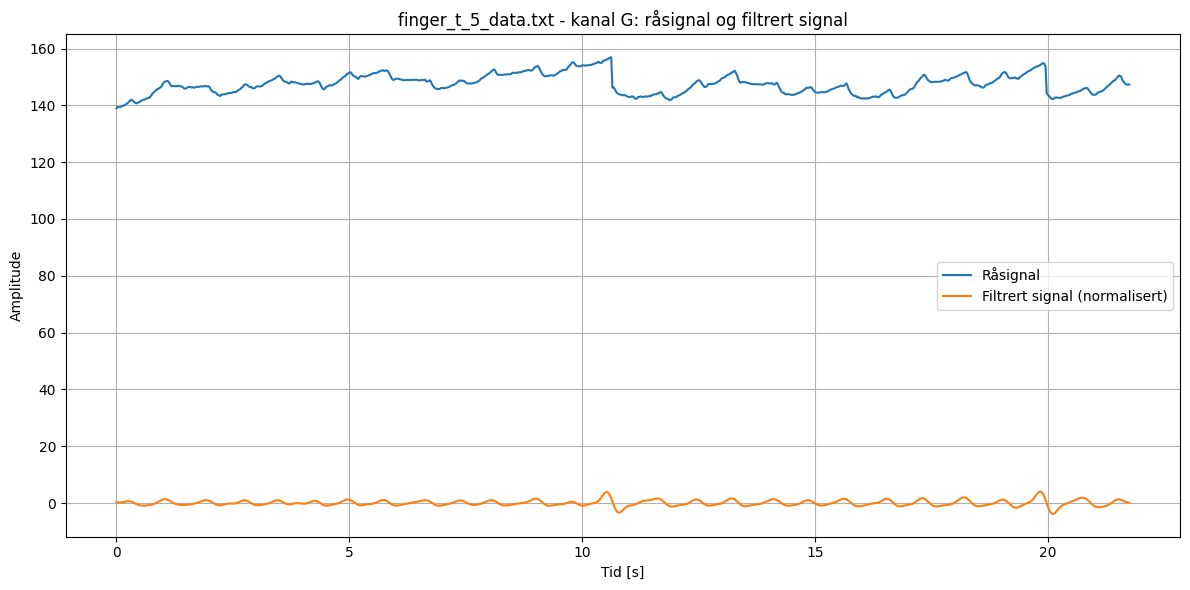

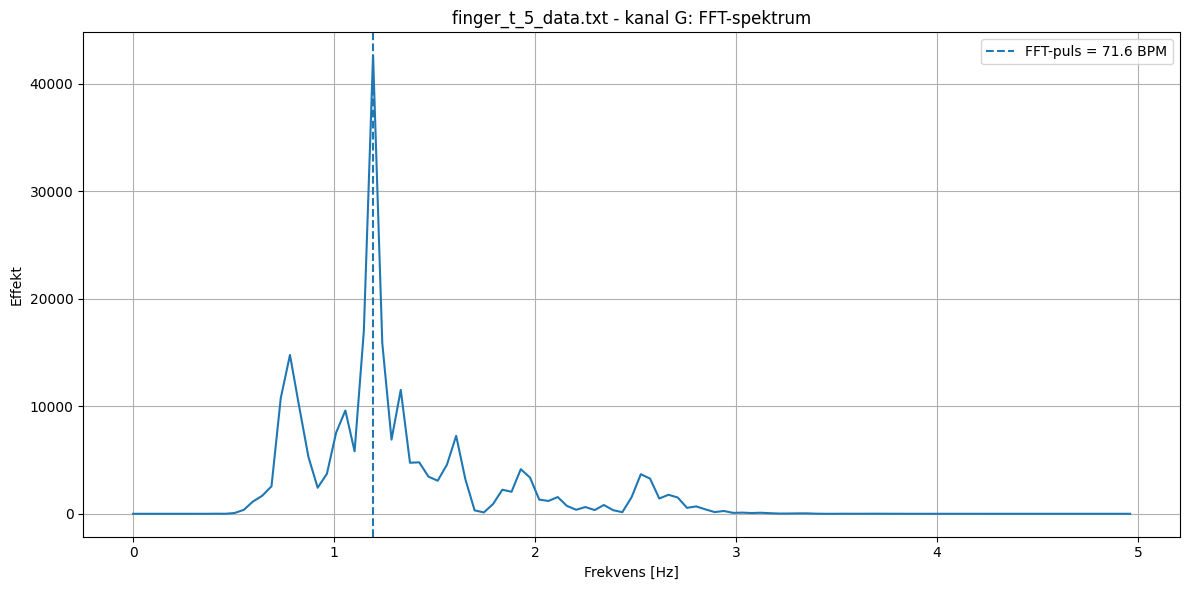

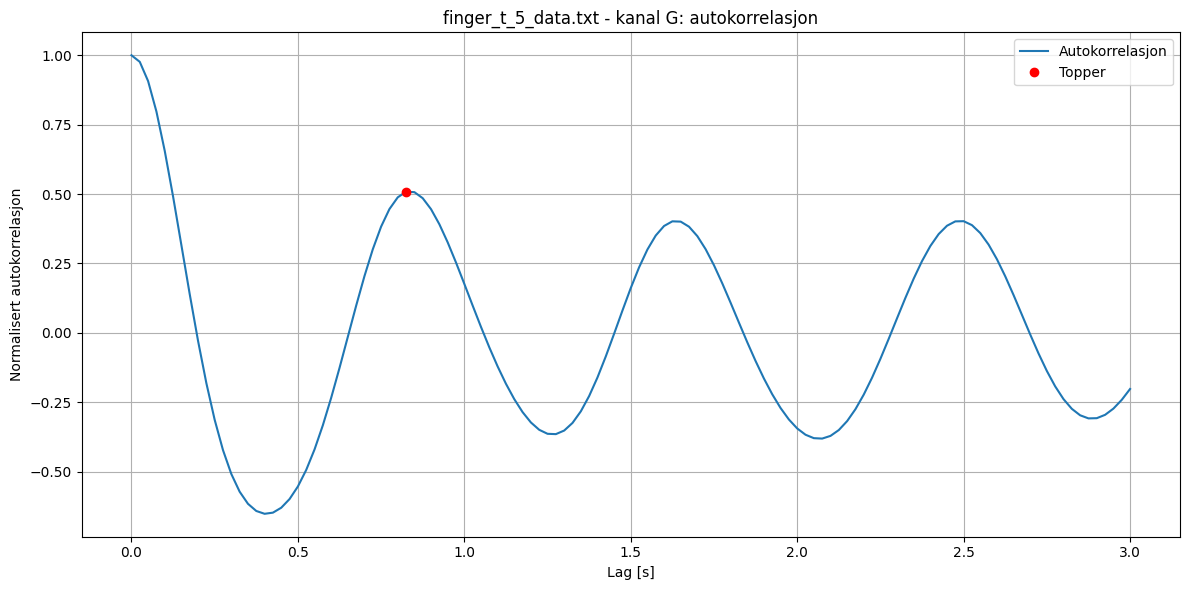


===== finger_t_56BMP_mob1_data.txt =====
Kanal analysert: G
Puls fra FFT:            82.66 BPM
Puls fra autokorrelasjon:80.00 BPM
Std.avvik i BPM-estimat: ikke nok topper
SNR (FFT-basert):        -3.03 dB


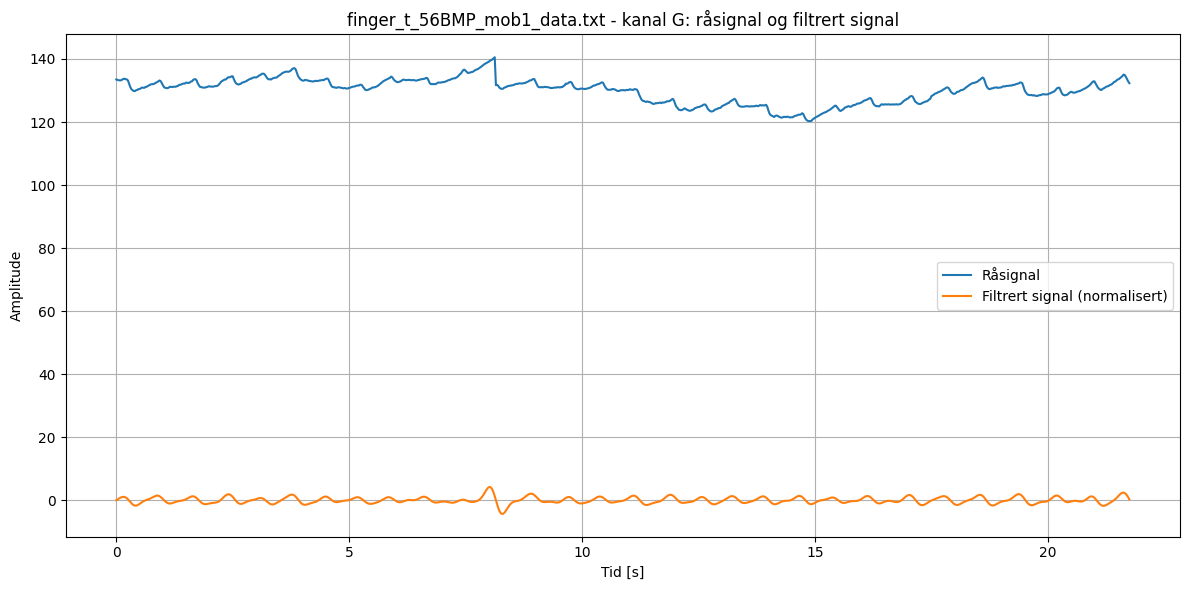

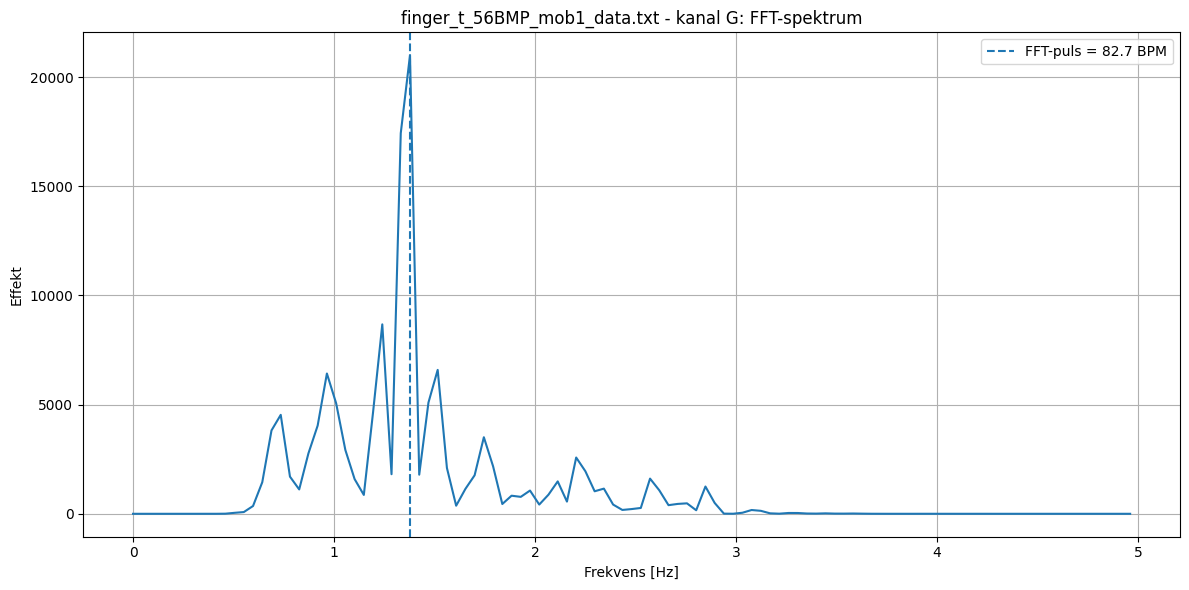

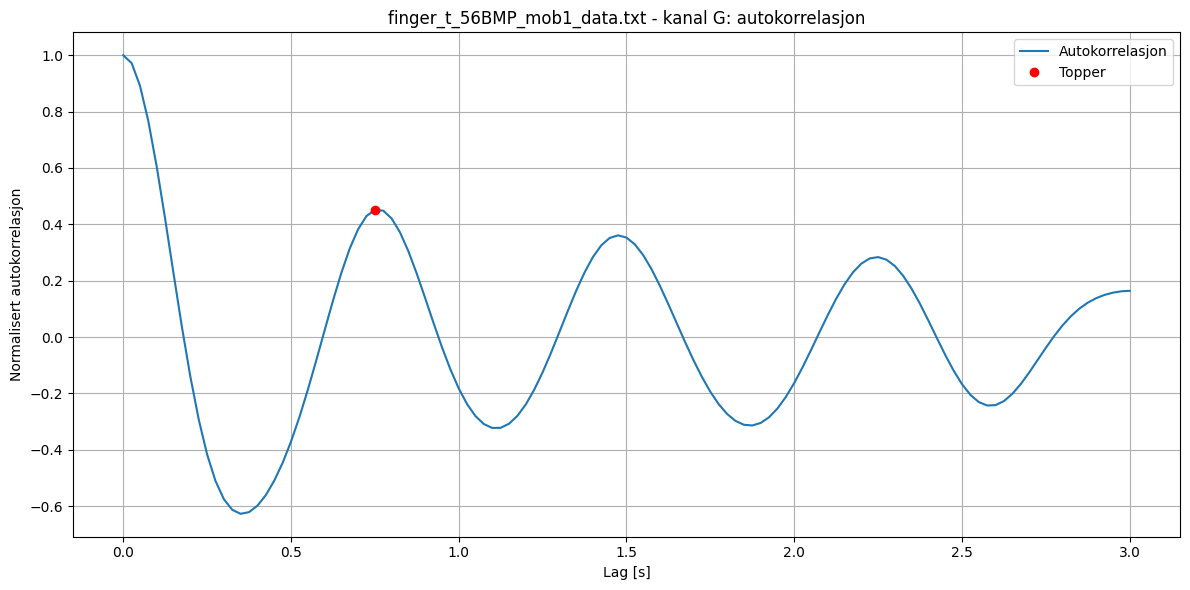

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks, detrend, correlate

# =========================================================
# INNSTILLINGER
# =========================================================
MAPPE = r'C:\Users\lisa\Desktop\6. semester\Sensorer og Instrumetering\Lab\Lab3\kode\data'

DATAFILER = [
    #'finger_burpees_data.txt',
    #'finger_test13_data.txt',
    #'finger_test14_data.txt',
    #'finger_t_2_data.txt',
    #'finger_t_3_data.txt',
    'finger_t_5_data.txt',
    'finger_t_56BMP_mob1_data.txt',
]

fps = 40  # frames per sekund

# Hvilken kanal vil du analysere?
# Basert på plottene dine er G mest aktuell
KANAL = 'G'   # 'R', 'G' eller 'B'

# Start litt ut i signalet for å fjerne første sample/spike hvis ønskelig
START_AT_S = 0.5

# Forventet pulsområde (kan justeres)
MIN_BPM = 40
MAX_BPM = 180

# Båndpassgrenser i Hz
LOWCUT_HZ = MIN_BPM / 60.0
HIGHCUT_HZ = MAX_BPM / 60.0

# Zero-padding faktor (for FFT-plot med vindu)
ZERO_PAD_FACTOR = 4

# =========================================================
# HJELPEFUNKSJONER
# =========================================================
def bandpass_filter(x, fs, lowcut, highcut, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, x)

def autocorr_normalized(x):
    ac = correlate(x, x, mode='full')
    ac = ac[len(ac)//2:]   # bare positive lags
    ac = ac / np.max(ac)   # normaliser
    return ac

def estimate_bpm_fft(x_filt, fs, min_bpm=40, max_bpm=180):
    N = len(x_filt)

    # Vindusfunksjon for penere spekter
    window = np.hanning(N)
    xw = x_filt * window

    X = np.fft.rfft(xw)
    freqs = np.fft.rfftfreq(N, d=1/fs)

    # Effekt-/powerspektrum
    Pxx = np.abs(X)**2

    # Kun relevant pulsområde
    fmin = min_bpm / 60.0
    fmax = max_bpm / 60.0
    mask = (freqs >= fmin) & (freqs <= fmax)

    if not np.any(mask):
        return np.nan, freqs, Pxx

    idx_peak = np.argmax(Pxx[mask])
    freqs_band = freqs[mask]
    f_peak = freqs_band[idx_peak]

    bpm_fft = 60 * f_peak
    return bpm_fft, freqs, Pxx

def estimate_bpm_autocorr(x_filt, fs, bpm_fft=np.nan, min_bpm=40, max_bpm=180):
    ac = autocorr_normalized(x_filt)
    lags = np.arange(len(ac)) / fs

    lag_min = 60 / max_bpm
    lag_max = 60 / min_bpm

    mask = (lags >= lag_min) & (lags <= lag_max)
    ac_valid = ac[mask]
    lags_valid = lags[mask]

    peaks, props = find_peaks(
        ac_valid,
        prominence=0.05,
        distance=int(fs * 0.3)
    )

    if len(peaks) == 0:
        return np.nan, np.nan, ac, lags, np.array([]), np.array([])

    peak_lags = lags_valid[peaks]

    # Første topp i autokorrelasjonen ER perioden direkte
    bpm_acf = 60 / peak_lags[0]

    # Std basert på alle enkelttopp-BPM-estimater
    all_bpms = 60 / peak_lags
    bpm_std = np.std(all_bpms, ddof=1) if len(all_bpms) >= 2 else np.nan

    return bpm_acf, bpm_std, ac, lags, peak_lags, peaks

def estimate_snr_fft(x_filt, fs, pulse_bpm, min_bpm=40, max_bpm=240):
    """
    Praktisk FFT-basert SNR:
    signalpower = effekt rundt grunnfrekvensen til pulsen (+ evt. 2. harmoniske)
    noisepower  = resten av effekten i det relevante frekvensområdet
    """
    if np.isnan(pulse_bpm):
        return np.nan

    N = len(x_filt)
    window = np.hanning(N)
    xw = x_filt * window

    X = np.fft.rfft(xw)
    freqs = np.fft.rfftfreq(N, d=1/fs)
    Pxx = np.abs(X)**2

    f0 = pulse_bpm / 60.0
    fmin = min_bpm / 60.0
    fmax = max_bpm / 60.0

    band_mask = (freqs >= fmin) & (freqs <= fmax)

    df = freqs[1] - freqs[0]
    bw = max(2 * df, 0.08)  # lite bånd rundt topp

    signal_mask = np.zeros_like(freqs, dtype=bool)

    # Ta med grunnfrekvens
    signal_mask |= (freqs >= (f0 - bw)) & (freqs <= (f0 + bw))

    # Ta med 2. harmoniske hvis den ligger i båndet
    f2 = 2 * f0
    if f2 <= fmax:
        signal_mask |= (freqs >= (f2 - bw)) & (freqs <= (f2 + bw))

    signal_power = np.sum(Pxx[signal_mask & band_mask])
    noise_power = np.sum(Pxx[(~signal_mask) & band_mask])

    if noise_power <= 0 or signal_power <= 0:
        return np.nan

    snr_db = 10 * np.log10(signal_power / noise_power)
    return snr_db

def analyze_signal(raw_signal, fs, kanalnavn="G"):
    # Fjern første del hvis ønskelig
    start_idx = int(START_AT_S * fs)
    x = raw_signal[start_idx:].astype(float)
    t = np.arange(len(x)) / fs

    # Detrend / fjern saktevarierende nivå
    x_detrended = detrend(x, type='linear')

    # Båndpass i pulsområdet
    x_filt = bandpass_filter(x_detrended, fs, LOWCUT_HZ, HIGHCUT_HZ, order=4)

    # Normaliser litt for plotting
    x_filt_plot = x_filt / np.std(x_filt) if np.std(x_filt) > 0 else x_filt

    # Puls fra FFT
    bpm_fft, freqs, Pxx = estimate_bpm_fft(
        x_filt, fs,
        min_bpm=MIN_BPM,
        max_bpm=MAX_BPM
    )

    # Puls fra autokorrelasjon
    bpm_acf, bpm_std, ac, lags, peak_lags, peaks = estimate_bpm_autocorr(
        x_filt, fs,
        min_bpm=MIN_BPM,
        max_bpm=MAX_BPM
    )

    # SNR: bruk autokorr-BPM hvis tilgjengelig, ellers FFT-BPM
    bpm_for_snr = bpm_acf if not np.isnan(bpm_acf) else bpm_fft
    snr_db = estimate_snr_fft(
        x_filt, fs,
        pulse_bpm=bpm_for_snr,
        min_bpm=MIN_BPM,
        max_bpm=240
    )

    results = {
        "t": t,
        "x_raw": x,
        "x_detrended": x_detrended,
        "x_filt": x_filt,
        "x_filt_plot": x_filt_plot,
        "freqs": freqs,
        "Pxx": Pxx,
        "bpm_fft": bpm_fft,
        "bpm_acf": bpm_acf,
        "bpm_std": bpm_std,
        "snr_db": snr_db,
        "ac": ac,
        "lags": lags,
        "peak_lags": peak_lags,
        "kanal": kanalnavn
    }

    return results

# =========================================================
# KJØR ANALYSE FOR HVER FIL
# =========================================================
for datafil in DATAFILER:
    filepath = os.path.join(MAPPE, datafil)
    data = np.loadtxt(filepath)

    R = data[:, 0]
    G = data[:, 1]
    B = data[:, 2]

    kanal_map = {"R": R, "G": G, "B": B}
    signal = kanal_map[KANAL]

    res = analyze_signal(signal, fps, kanalnavn=KANAL)

    print(f"\n===== {datafil} =====")
    print(f"Kanal analysert: {KANAL}")
    print(f"Puls fra FFT:            {res['bpm_fft']:.2f} BPM")
    print(f"Puls fra autokorrelasjon:{res['bpm_acf']:.2f} BPM")
    print(f"Std.avvik i BPM-estimat: {res['bpm_std']:.2f}" if not np.isnan(res['bpm_std']) else
          "Std.avvik i BPM-estimat: ikke nok topper")
    print(f"SNR (FFT-basert):        {res['snr_db']:.2f} dB")

    # ---------------------------------
    # Plot 1: Tidsdomene - råsignal og filtrert signal
    # ---------------------------------
    plt.figure(figsize=(12, 6))
    plt.plot(res["t"], res["x_raw"], label="Råsignal", alpha=0.7)
    plt.plot(res["t"], res["x_filt_plot"], label="Filtrert signal (normalisert)")
    plt.xlabel("Tid [s]")
    plt.ylabel("Amplitude")
    plt.title(f"{datafil} - kanal {KANAL}: tidsdomene")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------------------------------
    # Plot 2: FFT uten Hanning-vindu og zero-padding (rektangulært vindu)
    # ---------------------------------
    N_raw = len(res["x_filt"])
    X_raw = np.fft.rfft(res["x_filt"])
    freqs_raw = np.fft.rfftfreq(N_raw, d=1/fps)
    Pxx_raw = np.abs(X_raw)**2

    mask_raw = (freqs_raw >= 0) & (freqs_raw <= 5)
    f_peak_raw = freqs_raw[(freqs_raw >= MIN_BPM/60) & (freqs_raw <= MAX_BPM/60)][
        np.argmax(Pxx_raw[(freqs_raw >= MIN_BPM/60) & (freqs_raw <= MAX_BPM/60)])
    ]
    bpm_raw = 60 * f_peak_raw

    plt.figure(figsize=(12, 6))
    plt.plot(freqs_raw[mask_raw], Pxx_raw[mask_raw], label="Ingen vindu, ingen zero-padding")
    plt.axvline(bpm_raw / 60, color='r', linestyle="--", label=f"Topp = {bpm_raw:.1f} BPM")
    plt.xlabel("Frekvens [Hz]")
    plt.ylabel("Effekt")
    plt.title(f"{datafil} - kanal {KANAL}: FFT uten Hanning-vindu / zero-padding")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------------------------------
    # Plot 3: FFT med Hanning-vindu og zero-padding
    # ---------------------------------
    N_h = len(res["x_filt"])
    window_h = np.hanning(N_h)
    N_fft_h = ZERO_PAD_FACTOR * N_h
    X_h = np.fft.rfft(res["x_filt"] * window_h, n=N_fft_h)
    freqs_h = np.fft.rfftfreq(N_fft_h, d=1/fps)
    Pxx_h = np.abs(X_h)**2

    mask_h = (freqs_h >= 0) & (freqs_h <= 5)
    f_peak_h = freqs_h[(freqs_h >= MIN_BPM/60) & (freqs_h <= MAX_BPM/60)][
        np.argmax(Pxx_h[(freqs_h >= MIN_BPM/60) & (freqs_h <= MAX_BPM/60)])
    ]
    bpm_h = 60 * f_peak_h

    plt.figure(figsize=(12, 6))
    plt.plot(freqs_h[mask_h], Pxx_h[mask_h], label=f"Hanning-vindu, zero-padding x{ZERO_PAD_FACTOR}")
    plt.axvline(bpm_h / 60, color='r', linestyle="--", label=f"Topp = {bpm_h:.1f} BPM")
    plt.xlabel("Frekvens [Hz]")
    plt.ylabel("Effekt")
    plt.title(f"{datafil} - kanal {KANAL}: FFT med Hanning-vindu og zero-padding")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------------------------------
    # Plot 4: Autokorrelasjon
    # ---------------------------------
    plt.figure(figsize=(12, 6))
    lag_mask = (res["lags"] >= 0) & (res["lags"] <= 3)
    plt.plot(res["lags"][lag_mask], res["ac"][lag_mask], label="Autokorrelasjon")

    if len(res["peak_lags"]) > 0:
        peak_mask = res["peak_lags"] <= 3
        plt.plot(res["peak_lags"][peak_mask],
                 np.interp(res["peak_lags"][peak_mask], res["lags"], res["ac"]),
                 'ro', label="Topper")

    plt.xlabel("Lag [s]")
    plt.ylabel("Normalisert autokorrelasjon")
    plt.title(f"{datafil} - kanal {KANAL}: autokorrelasjon")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


===== finger_t_63BMP_data.txt =====
Kanal analysert: G
Puls fra FFT:            84.63 BPM
Puls fra autokorrelasjon:85.71 BPM
Std.avvik i BPM-estimat: 0.00
SNR (FFT-basert):        3.01 dB


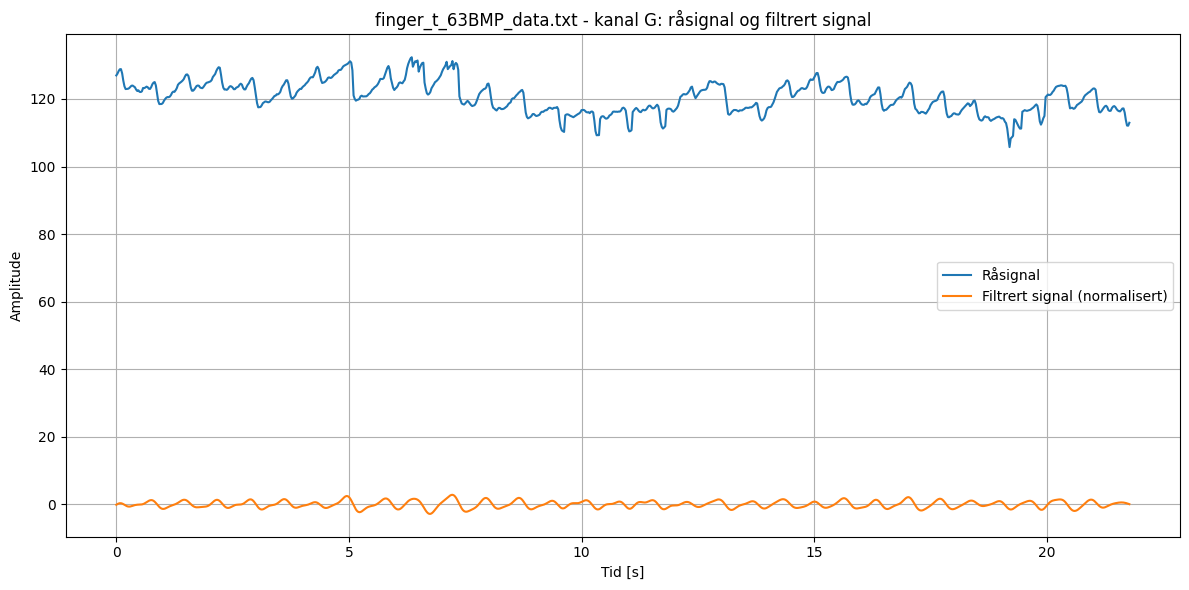

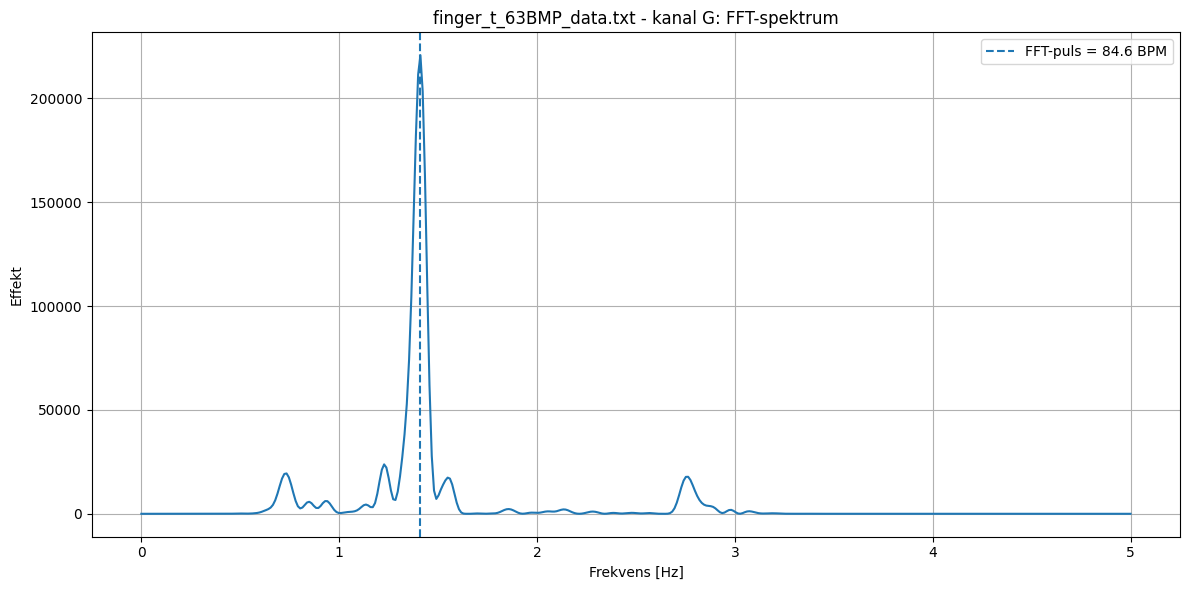

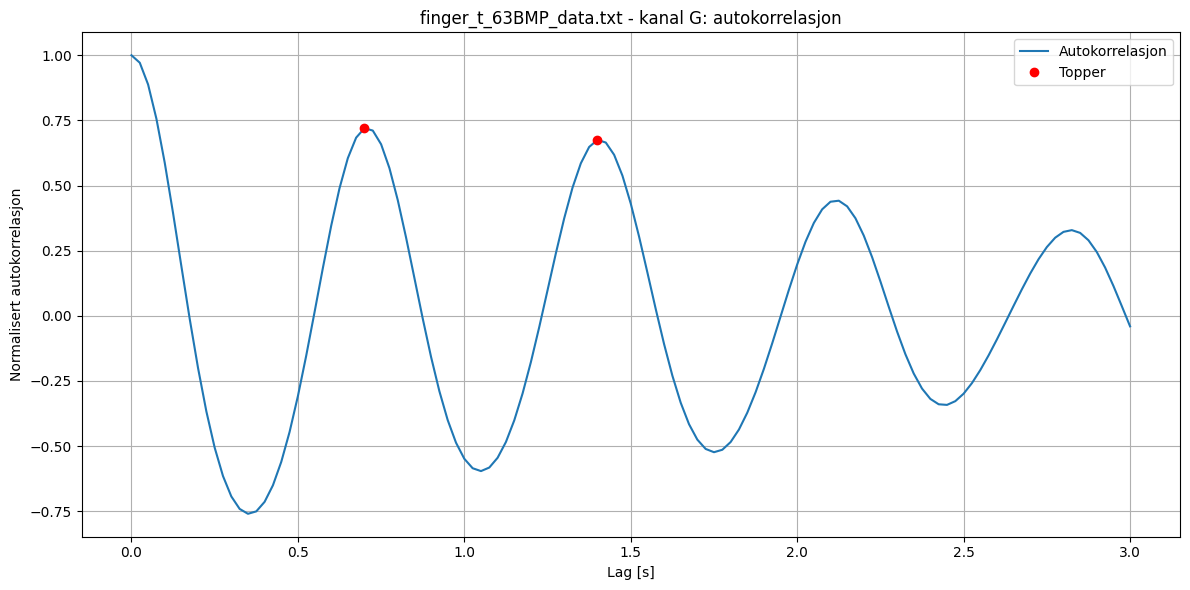

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks, detrend, correlate

# =========================================================
# INNSTILLINGER
# =========================================================
MAPPE = r'C:\Users\lisa\Desktop\6. semester\Sensorer og Instrumetering\Lab\Lab3\kode\data'

DATAFILER = [
    #'finger_burpees_data.txt',
    #'finger_test13_data.txt',
    #'finger_test14_data.txt',
    #'finger_t_2_data.txt',
    #'finger_t_3_data.txt',
    #'finger_t_5_data.txt',
    #'finger_t_56BMP_mob1_data.txt',
    #'finger_t_60BMP_lykt1_data.txt',
    'finger_t_63BMP_data.txt',
]

fps = 40  # frames per sekund

# Hvilken kanal vil du analysere?
KANAL = 'G'   # 'R', 'G' eller 'B'

# Start litt ut i signalet for å fjerne første sample/spike hvis ønskelig
START_AT_S = 0.5

# Forventet pulsområde (kan justeres)
MIN_BPM = 40
MAX_BPM = 180

# Båndpassgrenser i Hz
LOWCUT_HZ = MIN_BPM / 60.0
HIGHCUT_HZ = MAX_BPM / 60.0

# Zero-padding faktor
# 1 = ingen padding, 2 = dobbel lengde, 4 = fire ganger lengde, osv.
ZERO_PAD_FACTOR = 4

# =========================================================
# HJELPEFUNKSJONER
# =========================================================
def bandpass_filter(x, fs, lowcut, highcut, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, x)

def autocorr_normalized(x):
    ac = correlate(x, x, mode='full')
    ac = ac[len(ac)//2:]   # bare positive lags
    ac = ac / np.max(ac)   # normaliser
    return ac

def estimate_bpm_fft(x_filt, fs, min_bpm=40, max_bpm=180, zero_pad_factor=4):
    N = len(x_filt)

    # Hanning-vindu
    window = np.hanning(N)
    xw = x_filt * window

    # Zero-padding
    N_fft = zero_pad_factor * N

    X = np.fft.rfft(xw, n=N_fft)
    freqs = np.fft.rfftfreq(N_fft, d=1/fs)

    # Effekt-/powerspektrum
    Pxx = np.abs(X)**2

    # Kun relevant pulsområde
    fmin = min_bpm / 60.0
    fmax = max_bpm / 60.0
    mask = (freqs >= fmin) & (freqs <= fmax)

    if not np.any(mask):
        return np.nan, freqs, Pxx

    idx_peak = np.argmax(Pxx[mask])
    freqs_band = freqs[mask]
    f_peak = freqs_band[idx_peak]

    bpm_fft = 60 * f_peak
    return bpm_fft, freqs, Pxx

def estimate_bpm_autocorr(x_filt, fs, bpm_fft=np.nan, min_bpm=40, max_bpm=180):
    ac = autocorr_normalized(x_filt)
    lags = np.arange(len(ac)) / fs

    lag_min = 60 / max_bpm
    lag_max = 60 / min_bpm

    mask = (lags >= lag_min) & (lags <= lag_max)
    ac_valid = ac[mask]
    lags_valid = lags[mask]

    peaks, props = find_peaks(
        ac_valid,
        prominence=0.05,
        distance=int(fs * 0.3)
    )

    if len(peaks) == 0:
        return np.nan, np.nan, ac, lags, np.array([]), np.array([])

    peak_lags = lags_valid[peaks]

    # Første topp i autokorrelasjonen ER perioden direkte
    bpm_acf = 60 / peak_lags[0]

    # Std basert på alle enkelttopp-BPM-estimater
    all_bpms = 60 / peak_lags
    bpm_std = np.std(all_bpms, ddof=1) if len(all_bpms) >= 2 else np.nan

    return bpm_acf, bpm_std, ac, lags, peak_lags, peaks

def estimate_snr_fft(x_filt, fs, pulse_bpm, min_bpm=40, max_bpm=240, zero_pad_factor=4):
    """
    Praktisk FFT-basert SNR:
    signalpower = effekt rundt grunnfrekvensen til pulsen (+ evt. 2. harmoniske)
    noisepower  = resten av effekten i det relevante frekvensområdet
    """
    if np.isnan(pulse_bpm):
        return np.nan

    N = len(x_filt)

    # Hanning-vindu
    window = np.hanning(N)
    xw = x_filt * window

    # Zero-padding
    N_fft = zero_pad_factor * N

    X = np.fft.rfft(xw, n=N_fft)
    freqs = np.fft.rfftfreq(N_fft, d=1/fs)
    Pxx = np.abs(X)**2

    f0 = pulse_bpm / 60.0
    fmin = min_bpm / 60.0
    fmax = max_bpm / 60.0

    band_mask = (freqs >= fmin) & (freqs <= fmax)

    df = freqs[1] - freqs[0]
    bw = max(2 * df, 0.08)

    signal_mask = np.zeros_like(freqs, dtype=bool)

    # Ta med grunnfrekvens
    signal_mask |= (freqs >= (f0 - bw)) & (freqs <= (f0 + bw))

    # Ta med 2. harmoniske hvis den ligger i båndet
    f2 = 2 * f0
    if f2 <= fmax:
        signal_mask |= (freqs >= (f2 - bw)) & (freqs <= (f2 + bw))

    signal_power = np.sum(Pxx[signal_mask & band_mask])
    noise_power = np.sum(Pxx[(~signal_mask) & band_mask])

    if noise_power <= 0 or signal_power <= 0:
        return np.nan

    snr_db = 10 * np.log10(signal_power / noise_power)
    return snr_db

def analyze_signal(raw_signal, fs, kanalnavn="G"):
    # Fjern første del hvis ønskelig
    start_idx = int(START_AT_S * fs)
    x = raw_signal[start_idx:].astype(float)
    t = np.arange(len(x)) / fs

    # Detrend / fjern saktevarierende nivå
    x_detrended = detrend(x, type='linear')

    # Båndpass i pulsområdet
    x_filt = bandpass_filter(x_detrended, fs, LOWCUT_HZ, HIGHCUT_HZ, order=4)

    # Normaliser litt for plotting
    x_filt_plot = x_filt / np.std(x_filt) if np.std(x_filt) > 0 else x_filt

    # Puls fra FFT
    bpm_fft, freqs, Pxx = estimate_bpm_fft(
        x_filt, fs,
        min_bpm=MIN_BPM,
        max_bpm=MAX_BPM,
        zero_pad_factor=ZERO_PAD_FACTOR
    )

    # Puls fra autokorrelasjon
    bpm_acf, bpm_std, ac, lags, peak_lags, peaks = estimate_bpm_autocorr(
        x_filt, fs,
        min_bpm=MIN_BPM,
        max_bpm=MAX_BPM
    )

    # SNR: bruk autokorr-BPM hvis tilgjengelig, ellers FFT-BPM
    bpm_for_snr = bpm_acf if not np.isnan(bpm_acf) else bpm_fft
    snr_db = estimate_snr_fft(
        x_filt, fs,
        pulse_bpm=bpm_for_snr,
        min_bpm=MIN_BPM,
        max_bpm=240,
        zero_pad_factor=ZERO_PAD_FACTOR
    )

    results = {
        "t": t,
        "x_raw": x,
        "x_detrended": x_detrended,
        "x_filt": x_filt,
        "x_filt_plot": x_filt_plot,
        "freqs": freqs,
        "Pxx": Pxx,
        "bpm_fft": bpm_fft,
        "bpm_acf": bpm_acf,
        "bpm_std": bpm_std,
        "snr_db": snr_db,
        "ac": ac,
        "lags": lags,
        "peak_lags": peak_lags,
        "kanal": kanalnavn
    }

    return results

# =========================================================
# KJØR ANALYSE FOR HVER FIL
# =========================================================
for datafil in DATAFILER:
    filepath = os.path.join(MAPPE, datafil)
    data = np.loadtxt(filepath)

    R = data[:, 0]
    G = data[:, 1]
    B = data[:, 2]

    kanal_map = {"R": R, "G": G, "B": B}
    signal = kanal_map[KANAL]

    res = analyze_signal(signal, fps, kanalnavn=KANAL)

    print(f"\n===== {datafil} =====")
    print(f"Kanal analysert: {KANAL}")
    print(f"Puls fra FFT:            {res['bpm_fft']:.2f} BPM")
    print(f"Puls fra autokorrelasjon:{res['bpm_acf']:.2f} BPM")
    print(f"Std.avvik i BPM-estimat: {res['bpm_std']:.2f}" if not np.isnan(res['bpm_std']) else
          "Std.avvik i BPM-estimat: ikke nok topper")
    print(f"SNR (FFT-basert):        {res['snr_db']:.2f} dB")

    # ---------------------------------
    # Plot 1: Tidsdomene - råsignal og filtrert signal
    # ---------------------------------
    plt.figure(figsize=(12, 6))
    plt.plot(res["t"], res["x_raw"], label="Råsignal", alpha=0.7)
    plt.plot(res["t"], res["x_filt_plot"], label="Filtrert signal (normalisert)")
    plt.xlabel("Tid [s]")
    plt.ylabel("Amplitude")
    plt.title(f"{datafil} - kanal {KANAL}: tidsdomene")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------------------------------
    # Plot 2: FFT uten Hanning-vindu og zero-padding (rektangulært vindu)
    # ---------------------------------
    N_raw = len(res["x_filt"])
    X_raw = np.fft.rfft(res["x_filt"])
    freqs_raw = np.fft.rfftfreq(N_raw, d=1/fps)
    Pxx_raw = np.abs(X_raw)**2

    mask_raw = (freqs_raw >= 0) & (freqs_raw <= 5)
    f_peak_raw = freqs_raw[(freqs_raw >= MIN_BPM/60) & (freqs_raw <= MAX_BPM/60)][
        np.argmax(Pxx_raw[(freqs_raw >= MIN_BPM/60) & (freqs_raw <= MAX_BPM/60)])
    ]
    bpm_raw = 60 * f_peak_raw

    plt.figure(figsize=(12, 6))
    plt.plot(freqs_raw[mask_raw], Pxx_raw[mask_raw], label="Ingen vindu, ingen zero-padding")
    plt.axvline(bpm_raw / 60, color='r', linestyle="--", label=f"Topp = {bpm_raw:.1f} BPM")
    plt.xlabel("Frekvens [Hz]")
    plt.ylabel("Effekt")
    plt.title(f"{datafil} - kanal {KANAL}: FFT uten Hanning-vindu / zero-padding")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------------------------------
    # Plot 3: FFT med Hanning-vindu og zero-padding
    # ---------------------------------
    N_h = len(res["x_filt"])
    window_h = np.hanning(N_h)
    N_fft_h = ZERO_PAD_FACTOR * N_h
    X_h = np.fft.rfft(res["x_filt"] * window_h, n=N_fft_h)
    freqs_h = np.fft.rfftfreq(N_fft_h, d=1/fps)
    Pxx_h = np.abs(X_h)**2

    mask_h = (freqs_h >= 0) & (freqs_h <= 5)
    f_peak_h = freqs_h[(freqs_h >= MIN_BPM/60) & (freqs_h <= MAX_BPM/60)][
        np.argmax(Pxx_h[(freqs_h >= MIN_BPM/60) & (freqs_h <= MAX_BPM/60)])
    ]
    bpm_h = 60 * f_peak_h

    plt.figure(figsize=(12, 6))
    plt.plot(freqs_h[mask_h], Pxx_h[mask_h], label=f"Hanning-vindu, zero-padding x{ZERO_PAD_FACTOR}")
    plt.axvline(bpm_h / 60, color='r', linestyle="--", label=f"Topp = {bpm_h:.1f} BPM")
    plt.xlabel("Frekvens [Hz]")
    plt.ylabel("Effekt")
    plt.title(f"{datafil} - kanal {KANAL}: FFT med Hanning-vindu og zero-padding")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------------------------------
    # Plot 4: Autokorrelasjon
    # ---------------------------------
    plt.figure(figsize=(12, 6))
    lag_mask = (res["lags"] >= 0) & (res["lags"] <= 3)
    plt.plot(res["lags"][lag_mask], res["ac"][lag_mask], label="Autokorrelasjon")

    if len(res["peak_lags"]) > 0:
        peak_mask = res["peak_lags"] <= 3
        plt.plot(res["peak_lags"][peak_mask],
                 np.interp(res["peak_lags"][peak_mask], res["lags"], res["ac"]),
                 'ro', label="Topper")

    plt.xlabel("Lag [s]")
    plt.ylabel("Normalisert autokorrelasjon")
    plt.title(f"{datafil} - kanal {KANAL}: autokorrelasjon")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()